In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.windows import Window
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.io import MemoryFile
from shapely import Polygon, Point, prepare
from shapely.strtree import STRtree
from os import cpu_count
from concurrent.futures import ThreadPoolExecutor
from threading import Lock
import pickle
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from src.mslandcover.config import MSTM_PROJ4, LEGEND_CLASSES, LEGEND_COLORS_HEX
from glob import glob
from pyproj import CRS
import os
from tqdm import tqdm
from typing import Union, List, Optional
import pymetis
from joblib import Parallel, delayed


plt.rcParams['font.family'] = 'Times New Roman'

In [2]:
def process_window(dataset_path, window):
    """Processes a single window of a raster file to extract footprint polygons."""
    with rio.open(dataset_path) as src:
        data = src.read(1, window=window)
        nodata = src.nodata
        transform = src.window_transform(window)

    # If the window is all nodata, return an empty list
    data_mask = data != nodata
    if not data_mask.any():
        return []

    # Extract shapes for valid data areas
    window_footprints = []
    shapes = rio.features.shapes(data_mask.astype(np.uint8), mask=data_mask, transform=transform, connectivity=8)
    for shape, val in shapes:
        if val == 1.0:
            # Create a polygon and add it to the list for this window
            footprint = Polygon(shape['coordinates'][0]).buffer(0)
            window_footprints.append(footprint)
    return window_footprints

# get footprint of the data - VA only
if os.path.exists('data/cpb_tests/cpb_footprint/cpb_footprint.shp'):
    cpb_footprint = gpd.read_file('data/cpb_tests/cpb_footprint/cpb_footprint.shp')
    crs = cpb_footprint.crs

else:
    # dataset_paths = glob('data/cpb_tests/cpb_2024/*.vrt')
    dataset_paths = ['./data/cpb_tests/cpb_2024/VA_lulc_2021_2024-Edition.vrt']
    footprints = []
    crs = None
    window_size = 16384

    for dataset_path in dataset_paths:
        print(f'Processing {dataset_path}')
        with rio.open(dataset_path) as src:
            if crs is None:
                crs = src.crs
            else:
                assert crs == src.crs, f'CRS mismatch: {crs} != {src.crs}'

            windows = [
                Window(
                    col_off, 
                    row_off, 
                    min(window_size, src.width - col_off), 
                    min(window_size, src.height - row_off)
                )
                for row_off in range(0, src.height, window_size)
                for col_off in range(0, src.width, window_size)
            ]
            
            with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
                results_iterator = executor.map(lambda w: process_window(dataset_path, w), windows)
                results = list(tqdm(results_iterator, total=len(windows), desc=f'Processing windows for {os.path.basename(dataset_path)}'))

            footprints.extend([item for sublist in results for item in sublist])
            
            # for i, window in enumerate(tqdm(windows, desc=f'Processing windows for {os.path.basename(dataset_path)}')):
            #     data = src.read(1, window=window)
            #     data_mask = data != src.nodata
            #     if not data_mask.any():
            #         continue
            #     shapes = rio.features.shapes(data_mask.astype(np.uint8), mask=data_mask, transform=src.window_transform(window), connectivity=8)
            #     for shape, val in shapes:
            #         if val == 1.0:
            #             footprint = Polygon(shape['coordinates'][0])
            #             footprint = footprint.buffer(0)
            #             footprints.append(footprint)

    cpb_footprint = gpd.GeoDataFrame(geometry=footprints, crs=crs)
    cpb_footprint = cpb_footprint.dissolve().reset_index(drop=True)
    os.makedirs('data/cpb_tests/cpb_footprint', exist_ok=True)
    cpb_footprint.to_file('data/cpb_tests/cpb_footprint/cpb_footprint.shp', driver='ESRI Shapefile')

In [3]:
def create_grid(
    polygon: Polygon,
    crs: Union[CRS, str, int] = 4326,
    cell_size: int = 1000,
    enable_progress_bar: bool = False,
    clip_to_polygon: bool = True,
) -> gpd.GeoDataFrame:
    """
    Generate a regular grid of square polygons covering a given input polygon.

    The grid is aligned to the bounding box of the input polygon and consists of 
    square cells of the specified size. Optionally, only grid cells that intersect 
    the input polygon are retained, and the cells can be clipped to the polygon 
    boundary.

    Parameters
    ----------
    polygon : shapely.geometry.Polygon
        The input polygon to cover with a grid.
    crs : pyproj.CRS, str or int, default=4326
        The coordinate reference system for the output GeoDataFrame.
    cell_size : int, default=1000
        The size of each grid cell along each side in the units of the CRS.
    enable_progress_bar : bool, default=False
        Whether to display progress bars during grid creation and filtering.
    clip_to_polygon : bool, default=True
        If True, grid cells will be clipped to the input polygon boundary.

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame containing the grid polygons, optionally clipped to the input polygon.
    """
    minx, miny, maxx, maxy = polygon.bounds
    x_coords = np.arange(minx, maxx + cell_size, cell_size)
    y_coords = np.arange(miny, maxy + cell_size, cell_size)
    
    # Create grid of polygons using numpy broadcasting
    x_grid, y_grid = np.meshgrid(x_coords, y_coords)
    grid_polygons = [
        Polygon([(x, y), (x + cell_size, y), (x + cell_size, y + cell_size), (x, y + cell_size)])
        for x, y in tqdm(zip(x_grid.ravel(), y_grid.ravel()), desc="Creating grid polygons", total=x_grid.size, unit="polygons", disable=not enable_progress_bar)
    ]
    prepare(polygon)  # Prepare the geometry for faster intersection checks
    
    # Filter polygons that intersect with the geometry
    grid_polygons = [grid_polygon for grid_polygon in tqdm(grid_polygons, desc="Filtering polygons", unit="polygons", disable=not enable_progress_bar) if polygon.contains(grid_polygon)]
    grid_gdf = gpd.GeoDataFrame(geometry=grid_polygons, crs=crs)
    
    if clip_to_polygon:
        grid_gdf = grid_gdf.intersection(polygon)
    
    return grid_gdf

# create grid over Mississippi
cpb_polygon = cpb_footprint.dissolve().geometry[0]

# x_min, y_min, x_max, y_max = cpb_polygon.bounds
# x_delta, y_delta = 256, 256

# grid_gdf = gpd.GeoDataFrame(
#     geometry=[Polygon([
#         (x, y), 
#         (x+x_delta, y),
#         (x+x_delta, y+y_delta),
#         (x, y+y_delta),
#     ]) for x in np.arange(x_min, x_max, x_delta) for y in np.arange(y_min, y_max, y_delta)], 
#     crs=crs,
# )

grid_gdf = create_grid(
    polygon=cpb_polygon,
    crs=crs,
    cell_size=256,  # size of the grid cells in meters
    enable_progress_bar=True,
    clip_to_polygon=False,
)

# keep only the grid cells that intersect the state
# grid_gdf = grid_gdf.loc[grid_gdf.intersects(cpb_polygon)]
# grid_gdf = grid_gdf.loc[grid_gdf.within(cpb_polygon)]
grid_gdf.to_parquet('./data/cpb_tests/sampling/grid.par') # NOTE: this file is in source projection
print(f'Total number of candidate patches: {len(grid_gdf)}')

Filtering polygons: 100%|██████████| 2304012/2304012 [12:40<00:00, 3029.12polygons/s] 


Total number of candidate patches: 1178185


In [ ]:
grid_gdf = gpd.read_parquet('./data/cpb_tests/sampling/grid.par')  # Load grid from parquet

# Create adjacency graph (4-neighbor)
# index_map = {idx: i for i, idx in enumerate(grid_gdf.index)}
# neighbors = [[] for _ in range(len(grid_gdf))]
# for i, cell in tqdm(grid_gdf.iterrows(), desc="Determining adjacencies", total=len(grid_gdf)):
#     # Find touching cells
#     touching = grid_gdf[grid_gdf.geometry.touches(cell.geometry)].index
#     for n in touching:
#         neighbors[index_map[i]].append(index_map[n])

# tree = STRtree(grid_gdf.geometry.values)
# Find candidate pairs
# pairs = tree.query_bulk(grid_gdf.geometry.values, predicate="touches")
# pairs is a 2×M array of indices
# neighbors = [[] for _ in range(len(grid_gdf))]
# for src, dst in tqdm(zip(*pairs), desc="Building adjacency list", total=pairs.shape[1]):
#     neighbors[src].append(dst)

def find_neighbors_chunk(start_idx, end_idx, geoms):
    tree = STRtree(geoms)
    neighbors_chunk = [[] for _ in range(end_idx - start_idx)]

    for local_idx, global_idx in enumerate(range(start_idx, end_idx)):
        geom = geoms[global_idx]
        candidate_indices = tree.query(geom, predicate="touches")
        for j in candidate_indices:
            if global_idx != j and geom.touches(geoms[j]):
                neighbors_chunk[local_idx].append(j)
    return start_idx, neighbors_chunk

tree = STRtree(grid_gdf.geometry.values)
n = len(grid_gdf)
# geom_id_to_idx = {g: i for i, g in enumerate(grid_gdf.geometry.values)}

n_workers = cpu_count()  # Use all available CPU cores
chunk_size = (n + n_workers - 1) // n_workers  # Ceiling division

results = Parallel(n_jobs=n_workers)(
    delayed(find_neighbors_chunk)(i, min(i + chunk_size, n), grid_gdf.geometry.values)
    for i in range(0, n, chunk_size)
)

# Initialize neighbors list and populate results
neighbors = [[] for _ in range(n)]
for start_idx, neighbors_chunk in results:
    neighbors[start_idx:start_idx + len(neighbors_chunk)] = neighbors_chunk


# Partition into N strata
N = 250
n_cuts, membership = pymetis.part_graph(N, adjacency=neighbors)

# Add stratum assignment to GeoDataFrame
grid_gdf["spatial stratum"] = membership

grid_gdf.to_parquet('./data/cpb_tests/sampling/grid_with_spatial_strata.par')  # Save with strata

In [10]:
os.makedirs('./data/cpb_tests/sampling/spatial_strata_shapes', exist_ok=True)
grid_gdf.dissolve('spatial stratum').to_file('./data/cpb_tests/sampling/spatial_strata_shapes/spatial_strata.shp', driver='ESRI Shapefile')

/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_73848/227970627.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  grid_gdf.dissolve('spatial stratum').to_file('./data/cpb_tests/sampling/spatial_strata_shapes/spatial_strata.shp', driver='ESRI Shapefile')
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'spatial stratum' to 'spatial st'
  ogr_write(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'hist_vector' to 'hist_vecto'
  ogr_write(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'hist_vector_scaled' to 'hist_vec_1'
  ogr_write(
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'hist_vector_pca' to 'hist_ve

In [15]:
# clip NLCD data to grid
# could use state boundary, but some cells slightly protrude outside of the state
# better to use grid boundary

# grid_gdf = gpd.read_parquet('./data/cpb_tests/sampling/grid_with_spatial_strata.par')

with rio.open('./data/sampling/NLCD/Annual_NLCD_LndCov_2023_CU_C1V0.tif') as src:
    
    full_grid = grid_gdf.dissolve().to_crs(src.crs).buffer(256).geometry
    
    out_image, out_transform = mask(src, full_grid, crop=True, all_touched=True)
    out_meta = src.meta.copy()
    out_meta.update({
        'height': out_image.shape[1],
        'width': out_image.shape[2],
        'transform': out_transform,
    })
    
    # save masked data
    # with rio.open(f'./data/da/NLCD/NLCD_CPB.tif', 'w', **out_meta) as dst:
    with rio.open(f'./data/cpb_tests/NLCD/NLCD_CPB.tif', 'w', **out_meta) as dst:
        dst.write(out_image)

In [26]:
# reproject raster to CRS of CPB data
# with rio.open('./data/sampling/NLCD/NLCD_MS.tif') as src:
with rio.open('./data/cpb_tests/NLCD/NLCD_CPB.tif') as src:
    
    dest_transform, dest_width, dest_height = calculate_default_transform(
        src.crs, 
        grid_gdf.crs, 
        src.width, 
        src.height, 
        *src.bounds
    )
    
    out_meta = src.meta.copy()
    out_meta.update({
        'crs': grid_gdf.crs,
        'transform': dest_transform,
        'width': dest_width,
        'height': dest_height,
    })
    
    # with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM.tif', 'w', **out_meta) as dst:
    with rio.open('./data/cpb_tests/NLCD/NLCD_CPB_REPROJECTED.tif', 'w', **out_meta) as dst:
        
        reproject(
            source=rio.band(src, 1),
            destination=rio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs, 
            dst_transform=dest_transform,
            dst_crs=grid_gdf.crs, 
            resampling=Resampling.nearest,
        )

In [27]:
# # Reclassify from NLCD Level II to our land cover classes
# # 0: Nodata (250)
# # 1: Water (11)
# # 2: Impervious surfaces (21, 22)
# # 3: Raised structures (23, 24)
# # 4: Barren (31)
# # 5: Forest (41, 42, 43)
# # 6: Herbaceous (52, 71, 81, 95)
# # 7: Cultivated Crops (82)
# # 8: Unclassified (N/A)



reclassification_dict = {
    11: 1, # open water -> water
    21: 2, # developed, open space -> impervious surfaces
    22: 2, # developed, low intensity -> impervious surfaces
    23: 3, # developed, medium intensity -> raised structures
    24: 3, # developed, high intensity -> raised structures
    # 23: 2, # developed, medium intensity -> raised structures
    # 24: 2, # developed, high intensity -> raised structures
    # 21: 3, # developed, open space -> impervious surfaces
    # 22: 3, # developed, low intensity -> impervious surfaces
    31: 4, # barren land -> barren
    41: 5, # deciduous forest -> forest
    42: 5, # evergreen forest -> forest
    43: 5, # mixed forest -> forest
    90: 5, # woody wetlands -> forest
    52: 6, # shrub/scrub -> herbaceous
    71: 6, # grassland/herbaceous -> herbaceous
    81: 6, # pasture/hay -> herbaceous
    95: 6, # emergent herbaceous wetlands -> herbaceous
    82: 7, # cultivated crops -> cultivated crops
    250: 0, # nodata -> nodata
}

# Relc

# with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM.tif') as src:
with rio.open('./data/cpb_tests/NLCD/NLCD_CPB_REPROJECTED.tif') as src:
    data = src.read(1)
    meta = src.meta

reclassified_data = np.vectorize(reclassification_dict.get)(data)

# update metadata
meta.update({
    'dtype': rio.uint8,
    'count': 1,
    'nodata': 0,
    'compress': 'lz77',
})

# with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif', 'w', **meta) as dst:
with rio.open('./data/cpb_tests/NLCD/NLCD_CPB_REPROJECTED_reclassified.tif', 'w', **meta) as dst:
    dst.write(reclassified_data, 1)

In [28]:
# now for the fun part: extract zonal histograms from each grid cell
def extract_zonal_histogram(geom, src, lock):
    with lock:
        out_image, _ = mask(src, [geom], crop=True, all_touched=False, nodata=0)
    return dict(zip(*np.unique(out_image[0], return_counts=True)))

lock = Lock()
n_cpus = cpu_count()
# with MemoryFile(open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif', 'rb')) as memfile:
with MemoryFile(open('./data/cpb_tests/NLCD/NLCD_CPB_REPROJECTED_reclassified.tif', 'rb')) as memfile:
    with rio.open(memfile) as src:
        with ThreadPoolExecutor(4 * n_cpus) as executor:
            grid_counts = executor.map(
                lambda geom: extract_zonal_histogram(geom, src, lock),
                grid_gdf.geometry,
            )

# save grid counts
grid_counts = list(grid_counts)
# with open('./data/sampling/grid_counts.pkl', 'wb') as f:
with open('./data/cpb_tests/sampling/grid_counts.pkl', 'wb') as f:
    pickle.dump(grid_counts, f)

In [ ]:
# transform list of dicts with counts to list of vectors corresponding to histograms 
# that are all of the same dimensionality based on the unique values in the raster

# get unique values in data
unique_values = np.unique(np.concatenate([list(gc.keys()) for gc in grid_counts]))
values_map = {v: i for i, v in enumerate(unique_values)}

print(unique_values, values_map)

# create vectors of histograms
histograms = np.zeros((len(grid_counts), len(unique_values) - 1), dtype=int) # -1 to exclude nodata value
for i, grid_count in enumerate(grid_counts):
    for k, v in grid_count.items():
        # do not inlude nodata values (0)
        if k == 0:
            continue
        histograms[i, values_map[k-1]] = v # -1 to account for missing nodata value

# normalize histograms (each vector sums to 1)
histograms = histograms / histograms.sum(axis=1, keepdims=True)
# np.save('./data/sampling/histogram_vectors.npy', histograms)
np.save('./data/cpb_tests/sampling/histogram_vectors.npy', histograms)

grid_gdf['histogram'] = list(histograms)
grid_gdf = grid_gdf.loc[~grid_gdf['histogram'].apply(lambda x: np.isnan(x).any())]
grid_gdf.to_parquet('./data/cpb_tests/sampling/grid_with_histograms.par')

[0 1 2 3 4 5 6 7] {np.uint8(0): 0, np.uint8(1): 1, np.uint8(2): 2, np.uint8(3): 3, np.uint8(4): 4, np.uint8(5): 5, np.uint8(6): 6, np.uint8(7): 7}


/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_53503/3036764392.py:20: RuntimeWarning: invalid value encountered in divide
  histograms = histograms / histograms.sum(axis=1, keepdims=True)


In [5]:
# time to perform PCA and cluster
n_components = 2
n_clusters = 250
random_state = 1701

grid_gdf = gpd.read_parquet('./data/cpb_tests/sampling/grid_with_histograms.par')
histograms = np.stack(grid_gdf['histogram'].values)

scaler = RobustScaler() # robust to outliers
pca = PCA(n_components=n_components, random_state=random_state)
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)

hist_scaled = scaler.fit_transform(histograms)
hist_pca = pca.fit_transform(hist_scaled)

grid_gdf['hist_vector'] = [v for v in histograms]
grid_gdf['hist_vector_scaled'] = [v for v in hist_scaled]
grid_gdf['hist_vector_pca'] = [v for v in hist_pca]

print(f'Percent of variance explained by {n_components} principal components: {100*pca.explained_variance_ratio_.sum():.2f}%')
for i in range(pca.n_components_):
    print(f'PC{i+1} explains {100*pca.explained_variance_ratio_[i]:.2f}% of variance')

clusters = kmeans.fit_predict(hist_pca)
grid_gdf['cluster'] = clusters
print(f'Number of clusters: {n_clusters}')
print(f'Minimum number of samples in a cluster: {np.unique(clusters, return_counts=True)[1].min()}')

# grid_gdf.to_parquet(f'./data/sampling/grid_MSTM_{n_clusters}_clusters.par')
grid_gdf.to_parquet(f'./data/cpb_tests/sampling/grid_MSTM_{n_clusters}_clusters.par')

Percent of variance explained by 2 principal components: 93.65%
PC1 explains 65.82% of variance
PC2 explains 27.83% of variance
Number of clusters: 250
Minimum number of samples in a cluster: 382


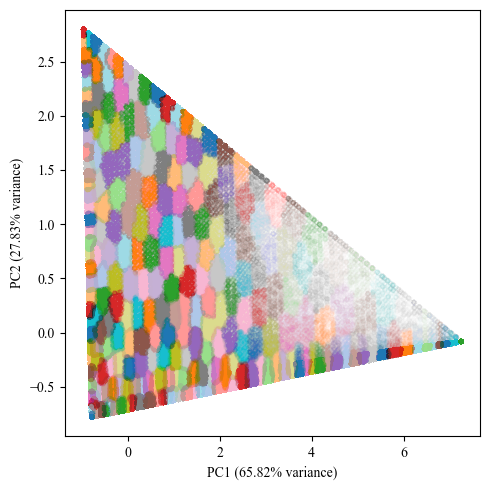

In [74]:
# plot clusters in PC space
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(hist_pca[:, 0], hist_pca[:, 1], c=clusters, cmap='tab20', s=10, alpha=0.01)
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.2f}% variance)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.2f}% variance)')
fig.tight_layout()
# os.makedirs('./paper/images/cpb_tests', exist_ok=True)
plt.savefig(f'./paper/images/cpb_clusters_{n_clusters}.pdf', dpi=300)
plt.show()

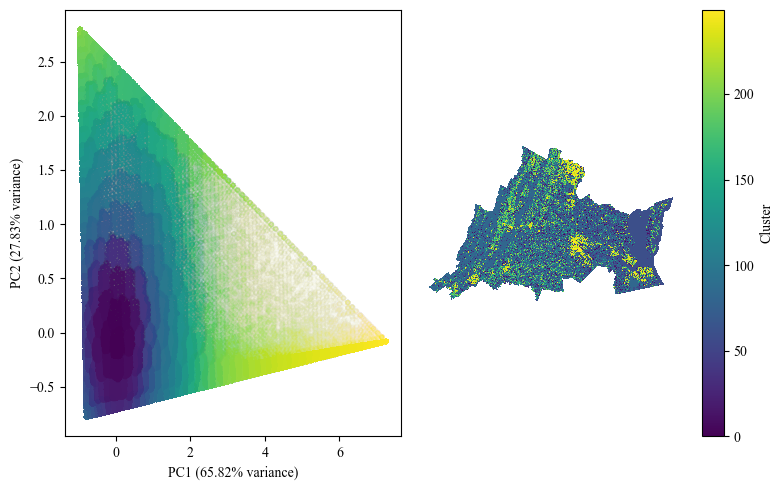

In [6]:
# visualize clusters on map
n_clusters = 250
grid_gdf = gpd.read_parquet(f'./data/cpb_tests/sampling/grid_MSTM_{n_clusters}_clusters.par')
grids_copy = grid_gdf.copy()

# order the clusters such that they can be colored in a way that clusters with
# similar values have similar colors

# get cluster centers
cluster_centers = pca.inverse_transform(kmeans.cluster_centers_)
# cluster_centers = scaler.inverse_transform(cluster_centers)

# get the order of the clusters based on the cluster centers
cluster_order = np.argsort(np.sum(np.square(kmeans.cluster_centers_), axis=1))

# map the cluster order to the original cluster labels
cluster_map = {cluster: i for i, cluster in enumerate(cluster_order)}
grids_copy['cluster'] = grids_copy['cluster'].map(cluster_map)

# plot clusters using PCs
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

scatter = ax[0].scatter(hist_pca[:, 0], hist_pca[:, 1], c=grids_copy['cluster'], cmap='viridis', s=10, alpha=0.01)
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')

grids_copy.plot(column='cluster', ax=ax[1], legend=True, cmap='viridis', legend_kwds={'label': 'Cluster'})
ax[1].axis('off')

fig.tight_layout()
plt.savefig('./paper/images/cpb_clusters_map.pdf', dpi=300)
plt.show()

In [3]:
reps = 10
folds = 4

for rep in range(reps):
    os.makedirs(f'./data/cpb_tests/splts/rep_{rep}', exist_ok=True)
    # first - simple random sampling
    srs_gdf = grid_gdf.sample(n=1000, random_state=rep)
    srs_gdf['split'] = [i % folds for i in range(len(srs_gdf))]
    srs_gdf.to_parquet(f'./data/cpb_tests/splts/rep_{rep}/srs.par')
    
    # next - spatially stratified sampling
    sss_gdf = gpd.GeoDataFrame(columns=grid_gdf.columns, crs=grid_gdf.crs)
    grid_copy = grid_gdf.copy()
    for stratum, stratum_gdf in grid_gdf.groupby('spatial stratum'):
        stratum_sample = stratum_gdf.sample(n=4, random_state=rep)
        stratum_sample['split'] = [int(fold) for fold in range(folds)]
        sss_gdf = pd.concat([sss_gdf, stratum_sample], ignore_index=False)
    sss_gdf.to_parquet(f'./data/cpb_tests/splts/rep_{rep}/sss.par')
            
    # finally - semantic stratified sampling
    semss_gdf = gpd.GeoDataFrame(columns=grid_gdf.columns, crs=grid_gdf.crs)
    for stratum, stratum_gdf in grid_gdf.groupby('cluster'):
        stratum_sample = stratum_gdf.sample(n=4, random_state=rep)
        stratum_sample['split'] = [int(fold) for fold in range(folds)]
        semss_gdf = pd.concat([semss_gdf, stratum_sample], ignore_index=False)
    semss_gdf.to_parquet(f'./data/cpb_tests/splts/rep_{rep}/semss.par')

In [4]:
n_clusters = 250
grid_gdf = gpd.read_parquet(f'./data/cpb_tests/sampling/grid_MSTM_{n_clusters}_clusters.par')

sampled_gdf_paths = glob('./data/cpb_tests/splts/rep_*/*.par')
print(f'Found {len(sampled_gdf_paths)} sampled files.')

gdfs = []
for path in sampled_gdf_paths:
    gdf = gpd.read_parquet(path)
    # gdf['sampling'] = path.split('/')[-1].replace('.par', '')
    # gdf['rep'] = int(path.split('/')[-2].split('_')[-1])
    gdfs.append(gdf)

sampled_tiles_gdf = pd.concat(gdfs, ignore_index=False)

# Create a GeoDataFrame of the individual buffered exclusion zones
exclusion_zones_gdf = gpd.GeoDataFrame(geometry=sampled_tiles_gdf.buffer(500), crs=grid_gdf.crs)

# Define the parallelizable function
def parallel_overlay_difference(chunk, exclusion_gdf):
    """Performs a difference overlay on a chunk of data."""
    return gpd.overlay(chunk, exclusion_gdf, how='difference', keep_geom_type=True)

# Get number of available cores
n_workers = cpu_count()
print(f"Splitting data into {n_workers} chunks for parallel processing...")

# Split the main grid into chunks
chunks = np.array_split(grid_gdf, n_workers)

# Run the overlay operation in parallel
results = Parallel(n_jobs=n_workers, verbose=1)(
    delayed(parallel_overlay_difference)(chunk, exclusion_zones_gdf) for chunk in chunks
)

# Concatenate the results from all parallel jobs
print("Concatenating results...")
candidate_tiles_gdf = pd.concat(results, ignore_index=True)

# Clean up any empty geometries that resulted from the difference
candidate_tiles_gdf = candidate_tiles_gdf[~candidate_tiles_gdf.is_empty]

print(f"Final number of candidate tiles: {len(candidate_tiles_gdf)}")

# exclusion_zone = sampled_tiles_gdf.buffer(500).union_all()
# prepare(exclusion_zone)

# # Create a GeoDataFrame for the exclusion zone to leverage spatial indexing
# exclusion_gdf = gpd.GeoDataFrame(geometry=[exclusion_zone], crs=grid_gdf.crs)

# # Find the indices of grid cells that intersect the exclusion zone
# intersecting_indices = grid_gdf.sjoin(exclusion_gdf, how="inner", predicate="intersects").index

# # Create a copy to modify. This will be our final result.
# candidate_tiles_gdf = grid_gdf.copy()

# # Get the subset of intersecting geometries
# intersecting_geoms = candidate_tiles_gdf.loc[intersecting_indices, 'geometry']

# # Perform the slow difference operation ONLY on the intersecting subset
# updated_geoms = intersecting_geoms.difference(exclusion_zone)

# # Update the geometry column in our copied GeoDataFrame with the new, clipped geometries
# candidate_tiles_gdf.loc[intersecting_indices, 'geometry'] = updated_geoms

candidate_tiles_gdf.to_parquet('./data/cpb_tests/sampling/candidate_test_tiles.par')

# test_candidate_gs = grid_gdf.difference(exclusion_zone)

# candidate_tiles_gdf = grid_gdf.copy()
# candidate_tiles_gdf['geometry'] = test_candidate_gs
# candidate_tiles_gdf = candidate_tiles_gdf[~candidate_tiles_gdf.is_empty]

Found 30 sampled files.
Splitting data into 10 chunks for parallel processing...


/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead

Concatenating results...
Final number of candidate tiles: 928681


In [5]:
candidate_tiles_gdf = gpd.read_parquet('./data/cpb_tests/sampling/candidate_test_tiles.par')

test_tiles = candidate_tiles_gdf.sample(n=50000, random_state=1701)

test_tiles.to_parquet('./data/cpb_tests/test_tiles.par')

In [7]:
test_tiles = gpd.read_parquet('./data/cpb_tests/test_tiles.par')
test_tiles

,geometry,spatial stratum,histogram,hist_vector,hist_vector_scaled,hist_vector_pca,cluster
637588,"POLYGON ((1477729 1819295, 1477985 1819295, 14...",159,"[0.0, 0.0, 0.0, 0.0, 0.5138888888888888, 0.486...","[0.0, 0.0, 0.0, 0.0, 0.5138888888888888, 0.486...","[0.0, 0.0, 0.0, 0.0, -0.0690298507462687, 1.66...","[-0.8697293108373936, 0.9591584677032201]",166
613997,"POLYGON ((1459297 1814175, 1459553 1814175, 14...",216,"[0.0, 0.0, 0.0, 0.0, 0.7916666666666666, 0.208...","[0.0, 0.0, 0.0, 0.0, 0.7916666666666666, 0.208...","[0.0, 0.0, 0.0, 0.0, 0.22947761194029845, 0.71...","[-0.8208975068443349, -0.03398159896128006]",8
41833,"POLYGON ((1360481 1690015, 1360481 1690271, 13...",225,"[0.0, 0.0, 0.0, 0.0, 0.013888888888888888, 0.9...","[0.0, 0.0, 0.0, 0.0, 0.013888888888888888, 0.9...","[0.0, 0.0, 0.0, 0.0, -0.6063432835820896, 3.38...","[-0.9576265580248993, 2.746810587699321]",86
843333,"POLYGON ((1552481 1889695, 1552737 1889695, 15...",138,"[0.027777777777777776, 0.05555555555555555, 0....","[0.027777777777777776, 0.05555555555555555, 0....","[0.027777777777777776, 0.4444444444444444, 0.0...","[-0.49690352154664647, 2.5429739579591297]",246
659101,"POLYGON ((1523553 1823903, 1523809 1823903, 15...",163,"[0.0, 0.125, 0.0, 0.0, 0.4027777777777778, 0.4...","[0.0, 0.125, 0.0, 0.0, 0.4027777777777778, 0.4...","[0.0, 1.0, 0.0, 0.0, -0.1884328358208955, 1.61...","[0.13709483803469635, 0.9966504694393199]",201
...,...,...,...,...,...,...,...
901117,"POLYGON ((1528673 1926827, 1528929 1926827, 15...",141,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 0.0, 0.0, 0.0, -0.6212686567164178, 3.42...","[-0.9600681482245523, 2.7964675910325463]",86
312195,"POLYGON ((1599073 1750175, 1599329 1750175, 15...",12,"[0.0, 0.984375, 0.0, 0.0, 0.015625, 0.0, 0.0]","[0.0, 0.984375, 0.0, 0.0, 0.015625, 0.0, 0.0]","[0.0, 7.875, 0.0, 0.0, -0.6044776119402985, 0....","[7.1252389956959, -0.09253823403872208]",232
87588,"POLYGON ((1584225 1701023, 1584225 1701279, 15...",58,"[0.0, 0.12345679012345678, 0.0, 0.0, 0.8765432...","[0.0, 0.12345679012345678, 0.0, 0.0, 0.8765432...","[0.0, 0.9876543209876543, 0.0, 0.0, 0.32068822...","[0.20770912014792775, -0.6927635575331618]",180
124982,"POLYGON ((1620577 1709471, 1620833 1709471, 16...",13,"[0.0, 0.3125, 0.0, 0.0, 0.328125, 0.015625, 0....","[0.0, 0.3125, 0.0, 0.0, 0.328125, 0.015625, 0....","[0.0, 2.5, 0.0, 0.0, -0.26865671641791045, 0.0...","[1.7580773623505697, -0.4234512104589344]",187


In [19]:
# sample pathces for training, testing, and validation sets - for each cluster, sample 4 patches
grid_gdf = gpd.read_parquet(f'./data/sampling/grid_MSTM_250_clusters.par')
random_state = 1701

n_train_samples_per_cluster = 2
n_val_samples_per_cluster = 1
n_test_samples_per_cluster = 1
n_pretraining_samples = int(0.2 * len(grid_gdf)) # sample 20% of total patches for pretraining
n_pretraining_val_samples = int(0.05 * len(grid_gdf)) # sample 5% of total patches for pretraining validation set

train_patches_gdf = grid_gdf.groupby('cluster').sample(n=n_train_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = grid_gdf[~grid_gdf.index.isin(train_patches_gdf.index)]

val_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_val_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(val_patches_gdf.index)]

test_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_test_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(test_patches_gdf.index)]

# sample pretraining last to enforce disjoint splits
pretraining_patches_gdf = remaining_candidate_patches_gdf.sample(n=n_pretraining_samples, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(pretraining_patches_gdf.index)]

pretraining_val_patches_gdf = remaining_candidate_patches_gdf.sample(n=n_pretraining_val_samples, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(pretraining_val_patches_gdf.index)]

print(f'Number of pretraining samples: {len(pretraining_patches_gdf)}')
print(f'Number of pretraining validation samples: {len(pretraining_val_patches_gdf)}')
print(f'Number of training samples: {len(train_patches_gdf)}')
print(f'Number of validation samples: {len(val_patches_gdf)}')
print(f'Number of testing samples: {len(test_patches_gdf)}')

for df, name in zip(
    [train_patches_gdf, val_patches_gdf, test_patches_gdf, pretraining_patches_gdf, pretraining_val_patches_gdf], 
    ['train', 'val', 'test', 'pretrain', 'pretrain_val']
):
    df['split'] = name

samples_gdf = pd.concat([pretraining_patches_gdf, pretraining_val_patches_gdf, train_patches_gdf, val_patches_gdf, test_patches_gdf])
samples_gdf.to_parquet('./data/sampling/samples.par')
remaining_candidate_patches_gdf.to_parquet('./data/sampling/remaining_candidate_patches.par')

Number of pretraining samples: 377921
Number of pretraining validation samples: 94480
Number of training samples: 500
Number of validation samples: 250
Number of testing samples: 250


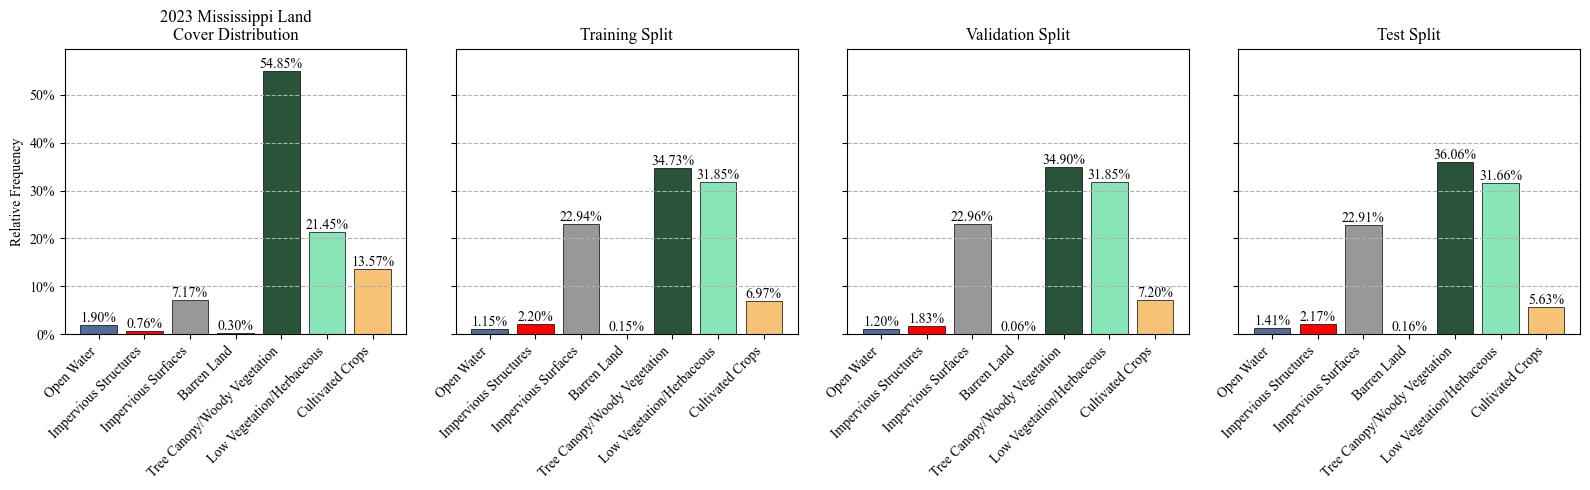

In [25]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import geopandas as gpd
# import rasterio as rio
# from src.mslandcover.config import LEGEND_CLASSES, LEGEND_COLORS_HEX

# plt.rcParams['font.family'] = 'Times New Roman'

# samples_gdf = pd.read_parquet('./data/sampling/samples.par')

# examine distributions of land cover classes in each split with respect to the full dataset
with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif') as src:
    full_dist = dict(zip(*np.unique(src.read(1), return_counts=True)))

# remove nodata from full distribution
full_dist.pop(0)

# normalize full distribution
full_dist = {k: v / sum(full_dist.values()) for k, v in full_dist.items()}

# NOTE: I got impervious surfaces and raised structures mixed up in the original reclassification mapping
# reclassify impervious surfaces to 3 and raised structures to 2
temp = full_dist[2]
full_dist[2] = full_dist[3]
full_dist[3] = temp

fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

# plot full distribution
ax[0].bar(full_dist.keys(), full_dist.values(), color=[LEGEND_COLORS_HEX[k] for k in full_dist.keys()], edgecolor='black', linewidth=0.5)
ax[0].set_title('2023 Mississippi Land\nCover Distribution')
ax[0].set_ylabel('Relative Frequency')
ax[0].set_xticks(list(full_dist.keys()))
ax[0].set_xticklabels([LEGEND_CLASSES[k] for k in full_dist.keys()], rotation=45, ha='right')
ax[0].grid(axis='y', linestyle='--')

# format y axis as percentage
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# add 0.05 to y axis limit to make room for text
ax[0].set_ylim(0, ax[0].get_ylim()[1] + 0.02)

# add values above bars
for k, v in full_dist.items():
    ax[0].text(k, v, f'{v:.2%}', ha='center', va='bottom')
    
hist_dict = {
    'split': [],
}
for k in full_dist.keys():
    class_name = LEGEND_CLASSES[k]
    hist_dict[class_name] = []

hist_dict['split'].append('NLCD')
for k in full_dist.keys():
    hist_dict[LEGEND_CLASSES[k]].append(full_dist[k])


# plot distribution of each split
split_titles = ['Training', 'Validation', 'Test']
split_names = ['train', 'val', 'test']

for i, split_name in enumerate(split_names):
    
    split_hist = np.array(list(samples_gdf[samples_gdf['split'] == split_name]['hist_vector']))
    split_hist = split_hist / split_hist.sum(axis=1, keepdims=True)
    
    split_hist = split_hist.mean(axis=0)
    split_dist = dict(zip(range(1, 9), split_hist))
    
    split_dist_temp = split_dist[2]
    split_dist[2] = split_dist[3]
    split_dist[3] = split_dist_temp
    
    ax[i+1].bar(split_dist.keys(), split_dist.values(), color=[LEGEND_COLORS_HEX[k] for k in split_dist.keys()], edgecolor='black', linewidth=0.5)
    ax[i+1].set_title(f'{split_titles[i]} Split')
    ax[i+1].set_xticks(list(split_dist.keys()))
    ax[i+1].set_xticklabels([LEGEND_CLASSES[k] for k in split_dist.keys()], rotation=45, ha='right')
    ax[i+1].grid(axis='y', linestyle='--')
    
    # add values above bars
    for k, v in split_dist.items():
        ax[i+1].text(k, v, f'{v:.2%}', ha='center', va='bottom')
    
    hist_dict['split'].append(split_titles[i])
    for k in split_dist.keys():
        hist_dict[LEGEND_CLASSES[k]].append(split_dist[k])

hist_df = pd.DataFrame(hist_dict)
hist_df.to_csv('./data/sampling/split_distributions.csv', index=False)
fig.tight_layout()
plt.savefig('./paper/images/sampling/split_distributions.png', dpi=300)

In [24]:
# save centroids of train, val, and test patches for visualization later
tvt_gdf = samples_gdf.loc[samples_gdf['split'].isin(['train', 'val', 'test'])].copy()
tvt_gdf['geometry'] = tvt_gdf['geometry'].map(lambda x: x.centroid)
tvt_gdf[['split', 'cluster', 'geometry']].to_file('./data/sampling/tvt_centroids.gpkg', driver='GPKG')

In [25]:
# Ideally, we want to minimize the number of patches that are entirely of one class
def mono_class(hist_vector):
    return sum(hist_vector == 1.0) == 1

full_grid_percent_single_class = 100 * len(grid_gdf[grid_gdf['hist_vector'].apply(mono_class)]) / len(grid_gdf)
samples_percent_single_class = 100 * len(tvt_gdf[tvt_gdf['hist_vector'].apply(mono_class)]) / len(tvt_gdf)

print(f'Percentage of patches that are entirely of one class in full grid: {full_grid_percent_single_class:.2f}%')
print(f'Percentage of patches that are entirely of one class in samples: {samples_percent_single_class:.2f}%')

Percentage of patches that are entirely of one class in full grid: 29.96%
Percentage of patches that are entirely of one class in samples: 1.90%


In [40]:
# legend
# 0: Nodata
# 1: Water
# 2: Impervious surfaces
# 3: Raised structures
# 4: Barren
# 5: Forest canopy
# 6: Herbaceous
# 7: Cultivated Crops

cpb_reclassification_dict = {
    0: 0,   # NoData
    10: 1,  # Tidal Waters -> Water
    11: 1,  # Lakes and Reservoirs -> Water
    12: 1,  # Riverine Ponds -> Water
    13: 1,  # Terrene Ponds -> Water
    14: 1,  # Streams and Rivers -> Water
    15: 1,  # Bare Shore -> Water
    20: 2,  # Roads -> Impervious surfaces
    21: 3,  # Structures -> Raised structures
    22: 2,  # Other Impervious -> Impervious surfaces
    23: 5,  # Tree Canopy Over Roads -> Forest canopy
    24: 5,  # Tree Canopy Over Structures -> Forest canopy
    25: 5,  # Tree Canopy Over Other Impervious -> Forest canopy
    26: 5,  # Tree Canopy Over Turf Grass -> Forest canopy
    27: 6,  # Turf Grass -> Herbaceous
    28: 4,  # Bare Developed -> Barren
    30: 4,  # Extractive Barren -> Barren
    31: 2,  # Extractive Impervious -> Impervious surfaces
    32: 2,  # Solar Field Panel Arrays -> Impervious surfaces
    33: 4,  # Solar Field Barren -> Barren
    34: 6,  # Solar Field Herbaceous -> Herbaceous
    35: 6,  # Solar Field Shrubland -> Herbaceous
    36: 4,  # Suspended Succession Barren -> Barren
    37: 6,  # Suspended Succession Herbaceous -> Herbaceous
    38: 6,  # Suspended Succession Shrubland -> Herbaceous
    40: 5,  # Forest -> Forest canopy
    41: 5,  # Forested Other -> Forest canopy
    42: 4,  # Natural Succession Barren -> Barren
    43: 6,  # Natural Succession Herbaceous -> Herbaceous
    44: 6,  # Natural Succession Shrubland -> Herbaceous
    45: 4,  # Harvested Forest Barren -> Barren
    46: 6,  # Harvested Forest Herbaceous -> Herbaceous
    50: 4,  # Riverine Wetlands Barren -> Barren
    51: 6,  # Riverine Wetlands Herbaceous -> Herbaceous
    52: 6,  # Riverine Wetlands Shrubland -> Herbaceous
    53: 5,  # Riverine Wetlands Forested Other -> Forest canopy
    54: 5,  # Riverine Wetlands Forest -> Forest canopy
    55: 5,  # Riverine Wetlands Harvested Forest -> Forest canopy
    60: 4,  # Terrene Wetlands Barren -> Barren
    61: 6,  # Terrene Wetlands Herbaceous -> Herbaceous
    62: 6,  # Terrene Wetlands Shrubland -> Herbaceous
    63: 5,  # Terrene Wetlands Forested Other -> Forest canopy
    64: 5,  # Terrene Wetlands Forest -> Forest canopy
    65: 5,  # Terrene Wetlands Harvested Forest -> Forest canopy
    70: 4,  # Tidal Wetlands Barren -> Barren
    71: 6,  # Tidal Wetlands Herbaceous -> Herbaceous
    72: 6,  # Tidal Wetlands Shrubland -> Herbaceous
    73: 5,  # Tidal Wetlands Forested Other -> Forest canopy
    74: 5,  # Tidal Wetlands Forest -> Forest canopy
    75: 5,  # Tidal Wetlands Harvested Forest -> Forest canopy
    80: 4,  # Cropland Barren -> Barren
    81: 7,  # Cropland Herbaceous -> Cultivated Crops
    82: 4,  # Orchards and Vineyards Barren -> Barren
    83: 7,  # Orchards and Vineyards Herbaceous -> Cultivated Crops
    84: 6,  # Orchards and Vineyards Shrubland -> Herbaceous
    85: 4,  # Pasture and Hay Barren -> Barren
    86: 7,  # Pasture and Hay Herbaceous -> Cultivated Crops
}

In [ ]:
# criteria for selecting points for accuracy assessment
# 1. points are stratified according to reclassified NLCD data (with occoruences of each class proportional to the square root of the class probability)
# 3. points are within the state boundary
# 4. points are note within the same grid cell as a sample patch (pretraining, train, val, or test)
# 5. no more than 1 point per grid cell

with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif') as src:
    data = src.read(1)
    
    # georeferencing functions
    row_col_to_xy = src.xy
    xy_to_row_col = src.index

# get distirbution of NLCD Level I classes
_, class_counts = np.unique(data, return_counts=True)
class_probs = class_counts / class_counts.sum()
# first class is nodoata, so remove it
class_probs = class_probs[1:] ** 0.5 # square root to increase the number of points for classes with lower probabilities

min_class = class_probs.min()

n_points_per_class = np.round(200 * class_probs / min_class).astype(int)
print(n_points_per_class, n_points_per_class.sum())

def sample_points(class_index, points_to_sample, data, ms_polygon, remaining_candidate_patches_gdf):
    
    running_class_points = 0
    sample_points = []
    while running_class_points < points_to_sample:
        
        row = np.random.randint(0, data.shape[0])
        col = np.random.randint(0, data.shape[1])
        
        # check to make sure point is of the correct class
        if data[row, col] != class_index:
            continue
        
        # transform row, col to x, y
        x, y = row_col_to_xy(row, col)
        point = Point(x, y)
        
        # check if point is within state boundary
        if not ms_polygon.contains(point):
            continue
        
        # check if point is in an eligible grid cell
        intersecting_grid_cell = remaining_candidate_patches_gdf.intersects(point)
        if intersecting_grid_cell.any():
            continue
        
        # remove grid cell that intersects point
        remaining_candidate_patches_gdf = remaining_candidate_patches_gdf.drop(remaining_candidate_patches_gdf[intersecting_grid_cell].index)
        # remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~intersecting_grid_cell]
        
        sample_points.append({
            'class': class_index,
            'geometry': point,
        })
        
        running_class_points += 1
        
        if running_class_points % 10 == 0:
            print(f'Class {class_index}: {running_class_points}/{points_to_sample} points sampled', end='\r')

    print(f'Class {class_index}: {running_class_points} points sampled')
    return sample_points

for i, n in enumerate(n_points_per_class):
    sample_points_futures = sample_points(i+1, n, data, ms_polygon, remaining_candidate_patches_gdf)

sample_points = list(sample_points_futures)
with open('./data/sampling/sample_points.pkl', 'wb') as f:
    pickle.dump(sample_points, f)

In [ ]:
from shapely.geometry import Point, MultiPolygon
from rtree import index
import random
import numpy as np
from tqdm import tqdm
import geopandas as gpd
from pyproj import Transformer
from shapely.ops import transform
from shapely import prepare
# Sampling random points within Mississippi while avoiding sampled areas and ensuring spatial constraints

# Load your data
grid_gdf = gpd.read_parquet('./data/sampling/grid_MSTM_250_clusters.par')
remaining_candidate_patches_gdf = gpd.read_parquet('./data/sampling/remaining_candidate_patches.par')
mississippi_gdf = gpd.read_file('./data/sampling/cb_2023_28_bg_500k').to_crs(grid_gdf.crs).dissolve()
ms_geom = mississippi_gdf.geometry.union_all()
prepare(ms_geom)  # Prepare for fast spatial queries


Bounds: 318558.0250545107 1042333.7855580238 650997.9536228201 1577862.0666693929


In [ ]:

# Setup parameters
random.seed(1701)
np.random.seed(1701)
total_sample_points = 25000
geom_buffer = 200 # distance from training patches in m
point_buffer = 1000 # min distance from sampled points in m

# Get bounds of Mississippi for random point generation
min_x, min_y, max_x, max_y = ms_geom.bounds
print('Bounds:', min_x, min_y, max_x, max_y)


Bounds: 318558.0250545107 1042333.7855580238 650997.9536228201 1577862.0666693929


In [ ]:

if True:
    # Create collection of exclusion zones (already sampled areas)
    sampled_locations = grid_gdf.loc[~grid_gdf.index.isin(remaining_candidate_patches_gdf.index)]
    exclusion_zones = sampled_locations.geometry.buffer(geom_buffer).to_list()
    # prepare(exclusion_zones)  # Prepare for fast spatial queries

    # Build R-tree index for fast spatial queries of exclusion zones
    idx = index.Index()
    for i, geom in enumerate(exclusion_zones):
        idx.insert(i, geom.bounds)
        prepare(geom)  # Prepare each geometry for fast spatial queries

# Function to check if a point is valid (in Mississippi but not in exclusion zones)
def is_valid_point(point):
    # First check if point is in Mississippi (faster check)
    if not ms_geom.contains(point):
        return False
    
    # Check if point intersects any exclusion zone
    for i in idx.intersection(point.bounds):
        if exclusion_zones[i].contains(point):
            return False
        # if isinstance(exclusion_zones, MultiPolygon):
        #     if exclusion_zones.geoms[i].contains(point):
        #         return False
        # else:
        #     if exclusion_zones.contains(point):
        #         return False
    
    return True

# Store sampled points and their buffers
sample_points = []
dynamic_exclusion_zones = []

# Sample points
with tqdm(total=total_sample_points, desc="Sampling points", unit="point") as pbar:
    attempts = 0
    max_attempts = total_sample_points * 100  # Safety to prevent infinite loops
    
    while len(sample_points) < total_sample_points and attempts < max_attempts:
        attempts += 1
        
        # Generate random point
        random_x = random.uniform(min_x, max_x)
        random_y = random.uniform(min_y, max_y)
        random_point = Point(random_x, random_y)
        
        # Check if point is valid
        if is_valid_point(random_point):
            # Check against dynamic exclusion zones (points we've already added)
            valid = True
            for buffer_zone in dynamic_exclusion_zones:
                if buffer_zone.contains(random_point):
                    valid = False
                    break
                    
            if valid:
                sample_points.append(random_point)
                # Add buffer for this point to dynamic exclusion zones
                buffer_zone = random_point.buffer(point_buffer)
                dynamic_exclusion_zones.append(buffer_zone)
                pbar.update(1)

# Create GeoDataFrame from sampled points
sample_points_gdf = gpd.GeoDataFrame(geometry=sample_points, crs=grid_gdf.crs)

transformer = Transformer.from_crs(sample_points_gdf.crs, 'EPSG:4326', always_xy=True)
sample_points_gdf['lat'] = sample_points_gdf.geometry.apply(lambda geom: transformer.transform(geom.x, geom.y)[1])
sample_points_gdf['lon'] = sample_points_gdf.geometry.apply(lambda geom: transformer.transform(geom.x, geom.y)[0])
sample_points_gdf['id'] = [f'{i:04d}' for i in range(len(sample_points_gdf))]

# Save the sampled points
sample_points_gdf.to_file('./data/sampling/random_sample_points.gpkg', driver='GPKG')

Sampling points: 100%|██████████| 10000/10000 [05:24<00:00, 30.84point/s]
